In [2]:
import torch
import psutil
import torch.nn.functional as F
import random
import matplotlib.pyplot  as plt
%matplotlib inline

In [3]:
def get_smart_device():
    # 1. Check if CUDA is available at all
    if not torch.cuda.is_available():
        print("CUDA not available. Using CPU.")
        return torch.device('cpu')
    
    # 2. Check power source via psutil
    battery = psutil.sensors_battery()
    
    # If a battery is detected and the power cable is NOT plugged in
    if battery is not None and not battery.power_plugged:
        print(f"⚠️ Battery detected ({battery.percent}%). Switching to CPU to avoid GPU power-throttling.")
        return torch.device('cpu')
    
    # 3. Cable plugged in -> Use GPU
    gpu_name = torch.cuda.get_device_name(0)
    print(f"⚡ Plugged in! Using GPU: {gpu_name}")
    return torch.device('cuda')

device = get_smart_device()


CUDA not available. Using CPU.


In [4]:
words = open('../data/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
# build dataset

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(chars) + 1

def build_dataset(words):
    block_size = 3 # context length
    X, Y = [],[]
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '----->', itos[ix])
            context = context[1:] + [ix] #crop and append

    if device == 'cuda':
        X = torch.tensor(X).to('cuda')
        Y = torch.tensor(Y).to('cuda')
    else:
        X = torch.tensor(X)
        Y = torch.tensor(Y)
    
    print(X.shape, Y.shape)
    return X, Y

In [6]:
# train split, dev/validation split, test split
# 80%, 10%, 10%

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])         #80%
Xdev, Ydev = build_dataset(words[n1:n2])     #10%
Xte, Yte = build_dataset(words[n2:])         #10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
# MLP
## parameters

device = get_smart_device()
n_emb = 10 # dim of the character embedding vectors
n_hidden = 200 # no of layers of the hidden layer in neuron
block_size=3


g = torch.Generator(device=device).manual_seed(2147483647) # for reproducability
C = torch.randn((vocab_size,n_emb),            generator=g, device=device)
W1 = torch.randn((n_emb*block_size, n_hidden), generator=g, device=device) * (5/3)/((n_emb * block_size)**0.5)  #0.2
# b1 = torch.randn(n_hidden,                     generator=g, device=device) * 0.01
W2 = torch.randn((n_hidden, vocab_size),       generator=g, device=device) * 0.01
b2 = torch.randn(vocab_size,                   generator=g, device=device) * 0

# batch normalization params
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]

num_parameters = sum(p.nelement() for p in parameters)

for p in parameters:
    p.requires_grad = True

lri = []
lossi = []
stepi = []

print(f"Num parameters: {num_parameters}")

CUDA not available. Using CPU.
Num parameters: 12097


In [9]:
max_steps = 200000
batch_size = 32


for i in range(max_steps):
    
    # mini bathing
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xtr[ix]]
    embcat = emb.view(emb.shape[0],-1)
    
    # linear layer
    hpreact = embcat @ W1 # + b1
    
    # batch normalization----------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani)/bnstdi + bnbias #Normalizing
    
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # batch normalization----------------------------------------------------
    
    # non-linearity
    h = torch.tanh(hpreact) # 32, 100 # hidden layer
    logits = h @ W2 + b2 # 32, 27 # output layer
    loss = F.cross_entropy(logits, Ytr[ix]) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  
    for p in parameters:
        p.data += -lr * p.grad
        
    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())
    
    if i%10000 == 0:
        print(f"{i}/{max_steps} = {loss.item()}")
    
    # break


0/200000 = 3.3212313652038574
10000/200000 = 2.381714105606079
20000/200000 = 2.0804991722106934
30000/200000 = 2.253831386566162
40000/200000 = 2.04860258102417
50000/200000 = 2.168351411819458
60000/200000 = 2.179621696472168
70000/200000 = 2.2157466411590576
80000/200000 = 2.782742500305176
90000/200000 = 1.9401973485946655
100000/200000 = 2.088287353515625
110000/200000 = 1.7345203161239624
120000/200000 = 1.8459125757217407
130000/200000 = 2.3234097957611084
140000/200000 = 2.3430614471435547
150000/200000 = 2.10351824760437
160000/200000 = 1.8370519876480103
170000/200000 = 2.133509635925293
180000/200000 = 1.963889479637146
190000/200000 = 2.4725773334503174


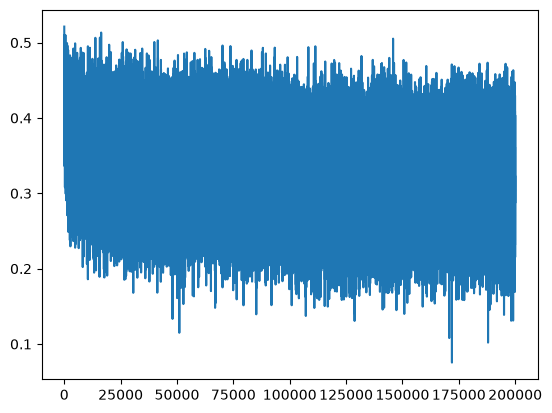

In [10]:
plt.plot(lossi)

In [12]:
#calibrate the batch norm at the end of training

with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1
    
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [14]:
@torch.no_grad()
def calc_loss(type):
    x, y = {
        'train': (Xtr,Ytr),
        'eval': (Xdev,Ydev),
        'test': (Xte,Yte),
        
    }[type]
    emb = C[x]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 #+ b1
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True) + bnbias #Normalizing
    hpreact = bngain * (hpreact - bnmean_running)/bnstd_running + bnbias
    h = torch.tanh(hpreact) # 32, 200
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)
    return loss

print(f"Train loss: {calc_loss('train')}")
print(f"Eval loss:  {calc_loss('eval')}")

Train loss: 2.0657360553741455
Eval loss:  2.1058242321014404


In [15]:
# loss

# original

# fix softmax being confidently being wrong

# fix tanh layer too saturated at init

# use semi principles kiaming init instead of hacky init

# add batch normalization
# Train loss: 2.0666749477386475
# Eval loss:  2.1063685417175293


In [19]:
# sampling

g = torch.Generator(device=device).manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1) #+ b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
        
    print(''.join(itos[i] for i in out))

chrishfaabullvinnigrlystety.
skandstef.
zhntef.
priyah.
prestuf.
staritzediivdnalexnndhliston.
fengbtks.
lillanniququhasthfgitarisskfinessirudylextephiahltnellystef.
prasmbryxtksyah.
mbrosbosgy.
ljssiasasraellestsa.
lucotzo.
berkshassubishammalmanrannsxemolottss.
vebdayvonnixlangbriphprigprissslynnkoluwanzlieghnnkhlynessantezamsseff.
kyam.
claothe.
boktobbyiv.
frannissindzes.
stiellistim.
roscepid.


In [37]:
class Linear:
    
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g)  #/fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.5):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # params trained with backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers trained with a running momentum
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
        
    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean)/torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * self.running_mean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * self.running_var
            return self.out
        
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)

layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # layers[-1].weight *= 0.1
    layers[-1].gamma *= 0.1

    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

57851


In [38]:
max_steps = 200000
batch_size = 32
ud = []

for i in range(max_steps):
    
    # mini bathing
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xtr[ix]]
    x = emb.view(emb.shape[0],-1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 1.0
    for p in parameters:
        p.data += -lr * p.grad
    
    if i%10000 == 0:
        print(f"{i}/{max_steps} = {loss.item()}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std()/p.data.std()).log10().item() for p in parameters])

    break


0/200000 = 3.253640651702881
